In [1]:
from fairdatanow import DataViewer
import os

In [91]:
configuration = {
    'url': "https://laboppad.nl/ukiyo-e-world", 
    'user':    os.getenv('NC_AUTH_USER'),
    'password': os.getenv('NC_AUTH_PASS')
}

In [93]:
dv = DataViewer(configuration)
dv

DataViewer(bytes_amount=1789810606, columns=['path', 'size', 'modified'], data=                                                  path       size    ext  \
0                                       ukiyo-e-world/    1.7 GiB          
1                              ukiyo-e-world/README.md  964 Bytes    .md   
2                                  ukiyo-e-world/data/    1.6 GiB          
3                              ukiyo-e-world/data/MFT/   14.2 MiB          
4                     ukiyo-e-world/data/MFT/README.md  588 Bytes    .md   
..                                                 ...        ...    ...   
337  ukiyo-e-world/figures/RS/2024-144_RS-i_yellows...  396.7 KiB   .png   
338  ukiyo-e-world/figures/RS/2024-144_RS-i_yellows...  446.5 KiB   .png   
339  ukiyo-e-world/figures/Wereldmuseum Leiden - Pr...   33.0 MiB  .pptx   
340                           ukiyo-e-world/notebooks/    0 Bytes          
341                             ukiyo-e-world/reports/    0 Bytes          

      byte_size                  modified  isdir  
0    1789810606 2026-03-09 13:17:02+00:00   True  
1           964 2026-01-14 09:58:36+00:00  False  
2    1673266559 2026-03-09 13:17:02+00:00   True  
3      14912171 2026-01-23 14:19:47+00:00   True  
4           588 2026-01-14 08:12:47+00:00  False  
..          ...                       ...    ...  
337      406227 2026-03-02 08:17:53+00:00  False  
338      457185 2026-03-02 08:17:02+00:00  False  
339    34605597 2026-02-25 14:18:59+00:00  False  
340           0 2026-01-14 07:27:23+00:00   True  
341           0 2026-01-14 07:31:02+00:00   True  

[342 rows x 6 columns], extensions=[], filtered_data=                                                  path       size  \
1                              ukiyo-e-world/README.md  964 Bytes   
4                     ukiyo-e-world/data/MFT/README.md  588 Bytes   
7    ukiyo-e-world/data/MFT/external/RMA_Japans-pre...  103.4 KiB   
8    ukiyo-e-world/data/MFT/external/RMA_Japans-pre...  515.1 KiB   
9    ukiyo-e-world/data/MFT/external/RMA_Japans-pre...  116.0 KiB   
..                                                 ...        ...   
335  ukiyo-e-world/figures/RS/2024-144_RS-i_yellows...  399.0 KiB   
336  ukiyo-e-world/figures/RS/2024-144_RS-i_yellows...  294.7 KiB   
337  ukiyo-e-world/figures/RS/2024-144_RS-i_yellows...  396.7 KiB   
338  ukiyo-e-world/figures/RS/2024-144_RS-i_yellows...  446.5 KiB   
339  ukiyo-e-world/figures/Wereldmuseum Leiden - Pr...   33.0 MiB   

                     modified  
1   2026-01-14 09:58:36+00:00  
4   2026-01-14 08:12:47+00:00  
7   2026-01-23 13:31:39+00:00  
8   2026-01-14 11:22:35+00:00  
9   2026-01-23 13:34:20+00:00  
..                        ...  
335 2026-03-02 08:18:49+00:00  
336 2026-03-02 08:18:25+00:00  
337 2026-03-02 08:17:53+00:00  
338 2026-03-02 08:17:02+00:00  
339 2026-02-25 14:18:59+00:00  

[305 rows x 3 columns], name='DataViewer00226', search='', show_directories=False, show_filters=False, use_regex=False)

In [107]:
wavelengths = np.loadtxt('wavelengths.txt')

In [7]:
files =  dv.download_selected()

Ready with downloading 4 selected remote files to local cache: /Users/tessa/.cache/fairdatanow                                                                                                                  


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time

from scipy.signal import savgol_filter, butter, filtfilt, find_peaks
from scipy.ndimage import gaussian_filter1d
import pandas as pd
import cv2
from matplotlib.colors import LogNorm
from matplotlib import gridspec

plt.rc('axes', labelsize = 12)
plt.rc('axes', titlesize = 12)
plt.rc('font', size = 10)
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.sans-serif'] = 'Cambria'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [79]:
def RGB(image, R=70,G=53,B=19):
    """
    Plots a false color plot of a Hyperspectral image:
    Input: np.array of HSI (bands, pixels, frames) and values for RGB bands.
    Output: matplotlib imshow image of false color plot (MxNx3)
    """

    image = image[[R,G,B],:,:]
    image = np.swapaxes(image, 0,2)
    image = np.swapaxes(image, 0,1) 
    image = image - np.min(image) #normalization
    image = image/np.max(image)
    plt.imshow(image)
    plt.xlabel('Frames')
    plt.ylabel('pixels')
    plt.show()

def loadHSI(data_file, dark_file):
    """
    Loads in 1 hyperspectral image:
    Input: Raw data file name and path for both the light and dark file
    Output: np.arrays for light and dark (bands, pixels, frames)
    """

    #Open data
    with open(data_file, 'rb') as file:
        data = np.fromfile(file, np.uint16)
    with open(dark_file, 'rb') as file:
        dark = np.fromfile(file, np.uint16)

    # Frames
    numF =  int(np.shape(data)[0]/(numP*numB)) #number of frames in data
    numF_d =  int(np.shape(dark)[0]/(numP*numB)) #number of frames in dark

    # Reshape
    data = np.reshape(data, (numP,numB,numF), order = 'F')
    data = np.swapaxes(data,axis1=0,axis2=1)

    dark = np.reshape(dark, (numP,numB,numF_d), order = 'F')
    dark = np.swapaxes(dark,axis1=0,axis2=1)
    return(data, dark) 

def extract_roi(cube, x, y, w, h, line, dark = False):
    #Input: nparray of HS image (bands, pixels, frames)
    # (x,y)= (frames,pixels) top left coordinate of ROI
    # width (w) and height (h) of ROI
    #Output: ROI and a bounding box used for imaging the ROI within the original image
    roi =  cube[:, y:y+h, x:x+w]
    box = np.copy(cube)
    if dark == False:
        intensity = 0
    if dark == True:
        intensity = np.max(cube)/2
    
    box[:, y:y+line, x:x+w+line] = intensity # top line
    box[:, y:y+h+line, x:x+line] = intensity # left line
    box[:, y+h:y+h+line, x:x+w+line] = intensity # bottom line
    box[:, y:y+h+line, x+w:x+w+line] = intensity # right line
    
    return roi, box

def correction(data, dark, white, white_dark):
    #Input: nparray of HS image before correction, dark frame, white selection (bands x pixels x fames)
    #Output: corrected HS image

    #Averages dark over the number of frames
    #dark_avg = dark.mean(axis = ) 
    #white_avg = white.mean()  
    #white_dark_avg = white_dark.mean()

    corr = (data - dark) / (white - white_dark +1e-10)

    return corr

In [81]:
numP = 512
numB = 204

for file in files:
    print(file)

data, dark = loadHSI(files[1], files[0])
white, white_dark = loadHSI(files[3], files[2]) 

/Users/tessa/.cache/fairdatanow/ukiyo-e-world/data/RIS/raw/KB129A10_2026-03-10_002/capture/DARKREF_KB129A10_2026-03-10_002.raw
/Users/tessa/.cache/fairdatanow/ukiyo-e-world/data/RIS/raw/KB129A10_2026-03-10_002/capture/KB129A10_2026-03-10_002.raw
/Users/tessa/.cache/fairdatanow/ukiyo-e-world/data/RIS/raw/KB129A10_2026-03-10_002/capture/WHITEDARKREF_KB129A10_2026-03-10_002.raw
/Users/tessa/.cache/fairdatanow/ukiyo-e-world/data/RIS/raw/KB129A10_2026-03-10_002/capture/WHITEREF_KB129A10_2026-03-10_002.raw


(204, 512, 512)
(204, 512, 1)
(204, 512, 1)
(204, 512, 1)


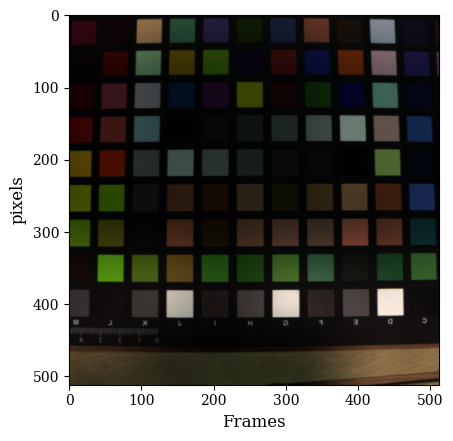

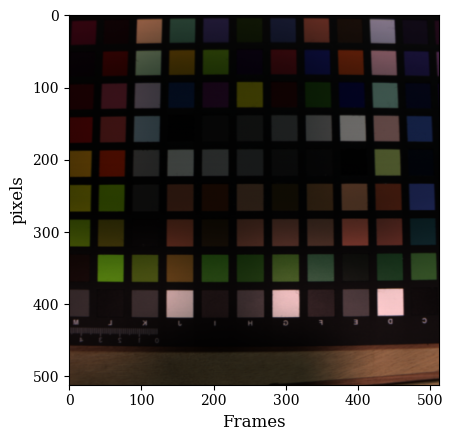

In [83]:
print(data.shape)
print(white.shape)
print(dark.shape)
print(white_dark.shape)

corr_data = correction(data, dark, white, white_dark)
RGB(data)
RGB(corr_data)

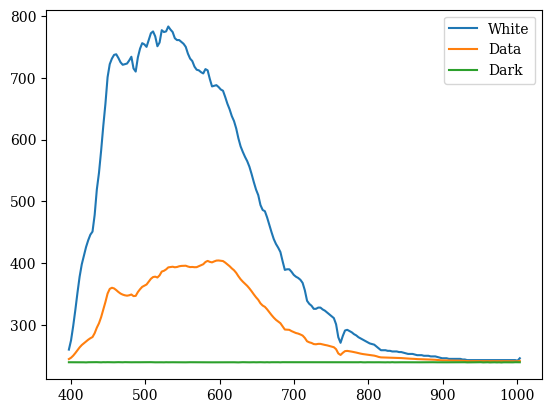

Average dark counts: 239


In [136]:
plt.figure()
plt.plot(wavelengths, np.mean(white, axis = (1,2)), label = 'White')
plt.plot(wavelengths, np.mean(data, axis = (1,2)), label = 'Data')
plt.plot(wavelengths, np.mean(dark, axis = (1,2)), label = 'Dark')
plt.legend()
plt.show()

print('Average dark counts:', int(np.mean(dark)))